![DB Academy](./Includes/images/db-academy.png)

# Lab - Create an HR Genie Space

#### Duration: ~10-15 Minutes

## Overview

In this lab, you will apply the skills from the previous demonstrations to create a **new Genie Space** on a different dataset.

You will work with an **HR dataset** that contains employee profiles, compensation details, manager information, and resignation records. 

Your goal is to explore the data, create a Genie Space, and add initial benchmarks.

**In this lab, you will NOT add any metadata, instructions, or SQL logic to the Knowledge Store.** That comes in the next lab.

## Learning Objectives

By the end of this lab, you will be able to:

1. **Explore a new dataset** and understand its tables, columns, and relationships.
2. **Create a Genie Space** using the HR tables.
3. **Define an audience and purpose** for the Genie Space.
4. **Add benchmark questions** with ground truth SQL to establish a baseline.

## REQUIRED - DATA SETUP

<div style="
  border-left: 4px solid #f44336;
  background: #ffebee;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#c62828; margin-bottom:6px; font-size: 1.1em;">Data Setup</strong>
  <div style="color:#333;">

Before starting this notebook, make sure you ran the **02 Demo - Bakehouse Setup and Data Exploration** notebook once to set up the course data.
  </div>
</div>


## REQUIRED - SELECT A COMPUTE ENVIRONMENT

<div style="
  border-left: 4px solid #f44336;
  background: #ffebee;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#c62828; margin-bottom:6px; font-size: 1.1em;">Select a Serverless SQL Warehouse</strong>
  <div style="color:#333;">

Before starting this notebook, select the required compute environment listed below.

- **Serverless SQL Warehouse (2X-Small is sufficient)**
  - Select **Compute** > **More** > **SQL Warehouse** > Select a SQL Warehouse you have access to.

**NOTE:** This notebook was **developed and tested using Serverless SQL Warehouse**. Other compute options may work but are not guaranteed to behave the same or support all features demonstrated.
  </div>
</div>

## A. Scenario, Audience, and Questions

<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    Scenario
  </strong>
  <div style="color:#333;">

You are an **HR People Analytics team member** at a mid-size company. 

Leadership is concerned about rising attrition and wants better visibility into workforce trends.

You met with stakeholders across the **HR Business Partner team**, **People Analytics**, and several **Department Heads** to understand what questions they need answered on a regular basis. They currently rely on ad-hoc SQL requests or spreadsheets and want a **self-service analytics tool** they can use without writing SQL.

You have been asked to build a **Genie Space** to support this.

  </div>
</div>

<!--
  HOW TO DIM A STEP DURING TEACHING:
  Each step card has its full-color inline styles AND a dimmed copy in a comment block above it.
  To dim a step: replace its <div ...> opening tag with the commented "DIM" version below it.
  To re-color: do the reverse.
-->

<div style="max-width: 1280px; margin: 0 auto; font-family: sans-serif; color: #0b2026;">

<!-- 6-STEP FLOW -->
<div style="display: grid; grid-template-columns: 1fr auto 1fr auto 1fr auto 1fr auto 1fr auto 1fr; gap: 0; align-items: stretch;">

  <!-- STEP 1 (active) -->
  <div style="background: #F9F7F4; border: 3px solid #2574B5; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;">
    <div style="font-size: 26pt; font-weight: 800; color: #2574B5; line-height: 1; margin-bottom: 8px;">1</div>
    <div style="font-size: 14pt; font-weight: 600; color: #0b2026; line-height: 1.35;">Start with purpose<br>and questions</div>
  </div>

  <div style="display: flex; align-items: center; justify-content: center; color: #618794; font-size: 22pt; line-height: 1;">&rarr;</div>

  <!-- STEP 2 (active) -->
  <div style="background: #F9F7F4; border: 3px solid #02A36F; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;">
    <div style="font-size: 26pt; font-weight: 800; color: #02A36F; line-height: 1; margin-bottom: 8px;">2</div>
    <div style="font-size: 14pt; font-weight: 600; color: #0b2026; line-height: 1.35;">Select a minimal<br>data slice</div>
  </div>

  <div style="display: flex; align-items: center; justify-content: center; color: #C2C2C2; font-size: 22pt; line-height: 1;">&rarr;</div>

  <!-- STEP 3 (DIMMED) -->
  <!-- ACTIVE: <div style="background: #F9F7F4; border: 3px solid #F8A805; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;"> -->
  <div style="background: #EEEDE9; border: 3px solid #C2C2C2; border-radius: 10px; padding: 16px 12px; box-shadow: none; text-align: center; min-width: 0; opacity: 0.7;">
    <div style="font-size: 26pt; font-weight: 800; color: #90A5B1; line-height: 1; margin-bottom: 8px;">3</div>
    <div style="font-size: 14pt; font-weight: 600; color: #5A6F77; line-height: 1.35;">Add metadata<br>and synonyms</div>
  </div>

  <div style="display: flex; align-items: center; justify-content: center; color: #C2C2C2; font-size: 22pt; line-height: 1;">&rarr;</div>

  <!-- STEP 4 (DIMMED) -->
  <!-- ACTIVE: <div style="background: #F9F7F4; border: 3px solid #FF5F46; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;"> -->
  <div style="background: #EEEDE9; border: 3px solid #C2C2C2; border-radius: 10px; padding: 16px 12px; box-shadow: none; text-align: center; min-width: 0; opacity: 0.7;">
    <div style="font-size: 26pt; font-weight: 800; color: #90A5B1; line-height: 1; margin-bottom: 8px;">4</div>
    <div style="font-size: 14pt; font-weight: 600; color: #5A6F77; line-height: 1.35;">Encode business<br>logic in SQL</div>
  </div>

  <div style="display: flex; align-items: center; justify-content: center; color: #C2C2C2; font-size: 22pt; line-height: 1;">&rarr;</div>

  <!-- STEP 5 (DIMMED) -->
  <!-- ACTIVE: <div style="background: #F9F7F4; border: 3px solid #98182A; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;"> -->
  <div style="background: #EEEDE9; border: 3px solid #C2C2C2; border-radius: 10px; padding: 16px 12px; box-shadow: none; text-align: center; min-width: 0; opacity: 0.7;">
    <div style="font-size: 26pt; font-weight: 800; color: #90A5B1; line-height: 1; margin-bottom: 8px;">5</div>
    <div style="font-size: 14pt; font-weight: 600; color: #5A6F77; line-height: 1.35;">Add light global<br>text instructions</div>
  </div>

  <div style="display: flex; align-items: center; justify-content: center; color: #C2C2C2; font-size: 22pt; line-height: 1;">&rarr;</div>

  <!-- STEP 6 (DIMMED) -->
  <!-- ACTIVE: <div style="background: #F9F7F4; border: 3px solid #1C3037; border-radius: 10px; padding: 16px 12px; box-shadow: 0 2px 8px rgba(27,49,57,0.08); text-align: center; min-width: 0;"> -->
  <div style="background: #EEEDE9; border: 3px solid #C2C2C2; border-radius: 10px; padding: 16px 12px; box-shadow: none; text-align: center; min-width: 0; opacity: 0.7;">
    <div style="font-size: 26pt; font-weight: 800; color: #90A5B1; line-height: 1; margin-bottom: 8px;">6</div>
    <div style="font-size: 14pt; font-weight: 600; color: #5A6F77; line-height: 1.35;">Test, benchmark,<br>and iterate with users</div>
  </div>

</div>

</div>


### Audience and Questions

**Target Audience:** HR Business Partners, People Analytics team, Department Heads

After meeting with stakeholders, here are the questions they want to ask:

- How many active employees do we have?
- What is the average salary by department?
- Who are our most underpaid employees?
- Which managers have the highest attrition on their teams?
- What are the top reasons employees are resigning?
- What does headcount look like by region?

<div style="
  border-left: 4px solid #f44336;
  background: #ffebee;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#c62828; margin-bottom:6px; font-size: 1.1em;">Important: No Metadata, Instructions, or SQL Logic Added Yet</strong>
  <div style="color:#333;">

In this first lab, you are **not** adding any of the following to the Genie Space:

- **Table or column metadata** - descriptions and synonyms
- **SQL logic** - joins, SQL expressions, or example queries
- **Sample questions** - example queries for Genie
- **Text instructions** - behavioral guidance

This is intentional. You will add these in the next lab to iteratively improve Genie's accuracy.
  </div>
</div>

## B. Classroom Setup

1. Run the cell below to initialize your environment. This setup step will:
    - Assume that you have **permission to create a catalog**
    - Create a catalog named **labuser_YOUR_USER_NAME**
    - Create a schema named **genie_course_hr**
    - Create the necessary HR tables

In [0]:
%run ./Includes/Classroom-Setup-lab-setup

2. Run the cell below to confirm the following **4 HR tables** exist in your schema:

    - **employees**
    - **compensation**
    - **managers**
    - **resignations**

In [0]:
SHOW TABLES IN genie_course_hr;

## C. HR Data Exploration

Before creating a Genie Space, you need to understand the data it will use.

> The **HR dataset** represents a fictional company's human resources data. It includes employee profiles, compensation details, manager information, and resignation records.

| Table | Description | Rows |
|-------|-------------|------|
| `employees` | Employee profiles including name, department, region, job title, and employment status | 800 |
| `compensation` | Compensation details including base salary, market benchmark, comp ratio, and last raise | 800 |
| `managers` | Manager profiles including department, region, team size, and performance rating | 60 |
| `resignations` | Resignation records including reason code, exit survey score, and last day | 140 |

### C1. Preview the Tables
Run the queries below to quickly preview each table and understand the data you will be working with.

1. View the **employees** table.

    Notice it contains:
      - an **employee_id** column (primary key)
      - employee details such as name, department, region, hire date, and job title
      - a **manager_id** column linking employees to their manager
      - a **status** column with values: `Active`, `Resigned`, or `Terminated`

In [0]:
-- Preview the employees table
SELECT *
FROM employees;

2. View the **compensation** table.

    Notice it contains:
      - an **employee_id** column linking to the employees table
      - salary details: **base_salary** and **market_benchmark**
      - a **comp_ratio** (base_salary / market_benchmark) indicating whether an employee is paid above or below market
      - raise history: **last_raise_date** and **last_raise_pct**

In [0]:
-- Preview the compensation table
SELECT *
FROM compensation;

3. View the **managers** table.

    Notice it contains:
      - a **manager_id** column (primary key)
      - manager details: name, department, and region
      - a **team_size** column and **performance_rating**
      - **start_date** and **end_date** columns (end_date is NULL for active managers)

In [0]:
-- Preview the managers table
SELECT *
FROM managers;

4. View the **resignations** table.

    Notice it contains:
      - a **resignation_id** column
      - an **employee_id** column linking to the employees table
      - **resignation_date** and **last_day** for tracking departure timeline
      - a **reason_code** with values such as: `Compensation`, `Career Growth`, `Manager Relationship`, `Personal`, `Relocation`, `Work-Life Balance`
      - an **exit_survey_score** (1-5 scale)

In [0]:
-- Preview the resignations table
SELECT *
FROM resignations;

### C2. Understand the Data Relationships

1. Understanding these relationships is important because Genie will need to join these tables when answering questions that span multiple tables.

For example:

- *"What is the average salary by department?"*
- *"Which managers have the most resignations?"*

The HR tables are related through the following keys:
<br></br>
<div style="max-width: 1280px; margin: 0 auto; font-family: sans-serif; color: #0b2026;">

<!-- 4 TABLE CARDS -->
<div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 14px; align-items: stretch; margin-bottom: 22px;">
  <div style="background: #FFFFFF; border: 2px solid #1B5162; border-radius: 8px; overflow: hidden; box-shadow: 0 2px 6px rgba(27,49,57,0.06);">
    <div style="background: #1B5162; color: white; padding: 10px 14px; font-family: monospace; font-size: 15pt; font-weight: 700;">employees</div>
    <div style="padding: 12px 14px; font-family: monospace; font-size: 13pt; line-height: 1.8;">
      <div style="color: #0b2026;"><b style="color: #1B5162;">PK</b> &nbsp;employee_id</div>
      <div style="color: #0b2026;"><b style="color: #98102A;">FK</b> &nbsp;manager_id</div>
      <div style="color: #5A6F77;">first_name</div>
      <div style="color: #5A6F77;">last_name</div>
      <div style="color: #5A6F77;">department</div>
      <div style="color: #5A6F77;">region</div>
      <div style="color: #5A6F77;">hire_date</div>
      <div style="color: #5A6F77;">job_title</div>
      <div style="color: #5A6F77;">job_level</div>
      <div style="color: #5A6F77;">status</div>
    </div>
  </div>
  <div style="background: #FFFFFF; border: 2px solid #1B5162; border-radius: 8px; overflow: hidden; box-shadow: 0 2px 6px rgba(27,49,57,0.06);">
    <div style="background: #1B5162; color: white; padding: 10px 14px; font-family: monospace; font-size: 15pt; font-weight: 700;">compensation</div>
    <div style="padding: 12px 14px; font-family: monospace; font-size: 13pt; line-height: 1.8;">
      <div style="color: #0b2026;"><b style="color: #98102A;">FK</b> &nbsp;employee_id</div>
      <div style="color: #5A6F77;">base_salary</div>
      <div style="color: #5A6F77;">market_benchmark</div>
      <div style="color: #5A6F77;">comp_ratio</div>
      <div style="color: #5A6F77;">last_raise_date</div>
      <div style="color: #5A6F77;">last_raise_pct</div>
    </div>
  </div>
  <div style="background: #FFFFFF; border: 2px solid #1B5162; border-radius: 8px; overflow: hidden; box-shadow: 0 2px 6px rgba(27,49,57,0.06);">
    <div style="background: #1B5162; color: white; padding: 10px 14px; font-family: monospace; font-size: 15pt; font-weight: 700;">managers</div>
    <div style="padding: 12px 14px; font-family: monospace; font-size: 13pt; line-height: 1.8;">
      <div style="color: #0b2026;"><b style="color: #1B5162;">PK</b> &nbsp;manager_id</div>
      <div style="color: #5A6F77;">manager_name</div>
      <div style="color: #5A6F77;">department</div>
      <div style="color: #5A6F77;">region</div>
      <div style="color: #5A6F77;">team_size</div>
      <div style="color: #5A6F77;">start_date</div>
      <div style="color: #5A6F77;">end_date</div>
      <div style="color: #5A6F77;">performance_rating</div>
    </div>
  </div>
  <div style="background: #FFFFFF; border: 2px solid #1B5162; border-radius: 8px; overflow: hidden; box-shadow: 0 2px 6px rgba(27,49,57,0.06);">
    <div style="background: #1B5162; color: white; padding: 10px 14px; font-family: monospace; font-size: 15pt; font-weight: 700;">resignations</div>
    <div style="padding: 12px 14px; font-family: monospace; font-size: 13pt; line-height: 1.8;">
      <div style="color: #0b2026;"><b style="color: #1B5162;">PK</b> &nbsp;resignation_id</div>
      <div style="color: #0b2026;"><b style="color: #98102A;">FK</b> &nbsp;employee_id</div>
      <div style="color: #5A6F77;">resignation_date</div>
      <div style="color: #5A6F77;">last_day</div>
      <div style="color: #5A6F77;">reason_code</div>
      <div style="color: #5A6F77;">exit_survey_score</div>
    </div>
  </div>
</div>

<!-- RELATIONSHIPS (simple list) -->
<div style="background: #F8F9FC; border: 1px solid #EEEDE9; border-radius: 8px; padding: 16px 20px;">
  <div style="font-size: 13pt; font-weight: 700; letter-spacing: 1.5px; color: #1B5162; text-transform: uppercase; margin-bottom: 10px;">Relationships</div>
  <div style="font-size: 14pt; line-height: 2; color: #0b2026;">
    <div><span style="font-family: monospace; font-weight: 700;">employees</span> &nbsp;&mdash;&mdash;&nbsp; <span style="background: #1B5162; color: white; font-size: 12pt; font-weight: 700; padding: 1px 8px; border-radius: 10px;">1 : 1</span> &nbsp;&mdash;&mdash;&nbsp; <span style="font-family: monospace; font-weight: 700;">compensation</span> &nbsp; on <code style="background: #FFFFFF; border: 1px solid #EEEDE9; padding: 2px 6px; border-radius: 3px; font-size: 13pt;">employee_id</code></div>
    <div><span style="font-family: monospace; font-weight: 700;">employees</span> &nbsp;&mdash;&mdash;&nbsp; <span style="background: #1B5162; color: white; font-size: 12pt; font-weight: 700; padding: 1px 8px; border-radius: 10px;">Many : 1</span> &nbsp;&mdash;&mdash;&nbsp; <span style="font-family: monospace; font-weight: 700;">managers</span> &nbsp; on <code style="background: #FFFFFF; border: 1px solid #EEEDE9; padding: 2px 6px; border-radius: 3px; font-size: 13pt;">manager_id</code></div>
    <div><span style="font-family: monospace; font-weight: 700;">employees</span> &nbsp;&mdash;&mdash;&nbsp; <span style="background: #1B5162; color: white; font-size: 12pt; font-weight: 700; padding: 1px 8px; border-radius: 10px;">1 : 0 or 1</span> &nbsp;&mdash;&mdash;&nbsp; <span style="font-family: monospace; font-weight: 700;">resignations</span> &nbsp; on <code style="background: #FFFFFF; border: 1px solid #EEEDE9; padding: 2px 6px; border-radius: 3px; font-size: 13pt;">employee_id</code></div>
  </div>
</div>

</div>



<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    A Note on Data Exploration
  </strong>
  <div style="color:#333;">

In production scenarios, it is important to **thoroughly explore and profile your data** before building a Genie Space.

Understanding distributions, nulls, edge cases, and business logic embedded in the data.

For this training, we have done a **brief, focused exploration**. Just enough to understand the tables and relationships before moving on to Genie.

  </div>
</div>

## D. Genie Project Architecture
<br></br>
<div style="max-width: 1280px; margin: 0 auto; font-family: sans-serif; color: #0b2026;">

<!-- TITLE BAR -->
<div style="background: #1B5162; color: white; border-radius: 8px; padding: 20px 28px; margin-bottom: 18px;">
  <div style="font-size: 22pt; font-weight: 700; margin-bottom: 6px;">HR Genie Project Architecture</div>
  <div style="font-size: 15pt; font-weight: 400; line-height: 1.45; opacity: 0.95;">Our goal is to link all of our Unity Catalog HR tables to a Genie Space where HR business users can <b>ask questions in natural language to obtain results.</b></div>
</div>

<!-- BEST PRACTICE CALLOUT -->
<div style="background: #FFF6F4; border-left: 4px solid #FF5F46; border-radius: 6px; padding: 12px 18px; margin-bottom: 22px; font-size: 14pt; line-height: 1.5;">
  <span style="font-size: 12pt; font-weight: 700; letter-spacing: 1.5px; color: #B83A24; text-transform: uppercase; display: block; margin-bottom: 4px;">Best Practice</span>
  It&rsquo;s best for a <b>data domain expert</b> to set up a Genie Space with <b>stakeholder involvement</b>.
</div>

<!-- FAN-IN/FAN-OUT ARCHITECTURE -->
<div style="display: grid; grid-template-columns: 1fr auto 1.1fr auto 0.95fr; gap: 0; align-items: center;">

  <!-- LEFT COLUMN: SOURCE TABLES -->
  <div>
    <div style="font-size: 12pt; font-weight: 700; letter-spacing: 2px; color: #1B5162; text-transform: uppercase; text-align: center; margin-bottom: 12px;">Unity Catalog Tables</div>
    <div style="display: flex; flex-direction: column; gap: 10px;">
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">employees</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Employee profiles and status</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">compensation</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Salary and market benchmarks</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">managers</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Manager profiles and ratings</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">resignations</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Departure reasons and surveys</div>
    </div>
    </div>
  </div>

  <!-- LEFT ARROW BUNDLE -->
  <div style="display: flex; flex-direction: column; align-items: center; padding: 0 14px;">
    <div style="font-size: 32pt; color: #618794; line-height: 1;">&rarr;</div>
    <div style="font-size: 12pt; color: #618794; font-style: italic; margin-top: 4px; text-align: center; max-width: 90px;">governed data</div>
  </div>

  <!-- CENTER: GENIE HUB -->
  <div style="background: #F9F7F4; border: 3px solid #FF5F46; border-radius: 14px; padding: 22px 18px; box-shadow: 0 6px 20px rgba(255,95,70,0.18); text-align: center; position: relative;">
    <div style="position: absolute; top: -12px; left: 50%; transform: translateX(-50%); background: #FF5F46; color: white; font-size: 11pt; font-weight: 700; letter-spacing: 1.5px; padding: 3px 14px; border-radius: 12px;">GENIE SPACE</div>
    <div style="margin: 10px 0 14px 0;">
      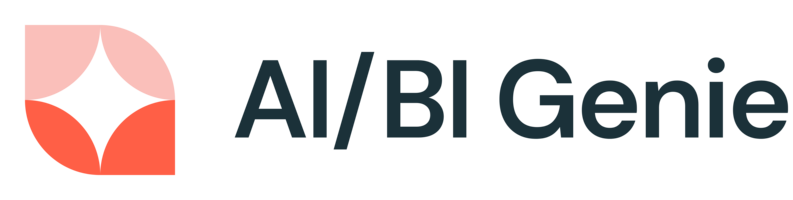
    </div>
    <div style="font-size: 16pt; font-weight: 700; color: #0b2026; line-height: 1.3; margin-bottom: 10px;">Ask questions in<br>natural language</div>
    <div style="background: #FFFFFF; border: 1.5px dashed #FF5F46; border-radius: 18px 18px 18px 4px; padding: 8px 14px; font-size: 13pt; font-style: italic; color: #5A6F77; text-align: left; margin-top: 12px;">
      &ldquo;Which managers have the most resignations this year?&rdquo;
    </div>
  </div>

  <!-- RIGHT ARROW BUNDLE -->
  <div style="display: flex; flex-direction: column; align-items: center; padding: 0 14px;">
    <div style="font-size: 32pt; color: #618794; line-height: 1;">&rarr;</div>
    <div style="font-size: 12pt; color: #618794; font-style: italic; margin-top: 4px; text-align: center; max-width: 90px;">answers &amp; charts</div>
  </div>

  <!-- RIGHT COLUMN: CONSUMERS -->
  <div>
    <div style="font-size: 12pt; font-weight: 700; letter-spacing: 2px; color: #00A972; text-transform: uppercase; text-align: center; margin-bottom: 12px;">Consumers</div>
    <div style="display: flex; flex-direction: column; gap: 12px;">
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">HR Business Partners</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">People Analytics</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">Department Heads</div>
    </div>
    </div>
  </div>

</div>

<!-- BOTTOM BAND: foundation note -->
<div style="margin-top: 24px; background: linear-gradient(135deg, #1B5162 0%, #0b2026 100%); color: #ffffff; border-radius: 8px; padding: 14px 22px; text-align: center;">
  <div style="font-size: 11pt; letter-spacing: 2.5px; text-transform: uppercase; color: #B7CDD5; font-weight: 700; margin-bottom: 4px;">Foundation</div>
  <div style="font-size: 14pt; color: #ffffff;">Unity Catalog &middot; one governed copy of your data &middot; permissions enforced end to end</div>
</div>

</div>



## E. Create the HR Genie Space

Now that you understand the data, create a Genie Space for the HR dataset.

<div style="max-width: 1200px; margin: 0 auto; font-family: sans-serif;">

<div style="background: #F9F7F4; border-radius: 10px; padding: 22px 26px; box-shadow: 0 2px 8px rgba(27,49,57,0.06); border-top: 6px solid #FF5F46;">

  <img src="./Includes/images/icons/genie-code.png" style="height: 44px; margin-bottom: 10px;">

  <div style="font-size: 18pt; font-weight: 700; color: #0b2026; margin-bottom: 12px;">
    Need Help? Use Genie Code
  </div>

  <div style="font-size: 15pt; color: #0b2026; line-height: 1.6; margin-bottom: 16px;">
    Genie is an AI-powered assistant that can help you as you work through this lab.
    Use it if you get stuck or want a little extra guidance.
  </div>

  <div style="display: flex; gap: 10px;">
    <a href="https://docs.databricks.com/aws/en/genie-code/" target="_blank" style="display: inline-block; background: #1B5162; color: white; font-size: 14pt; font-weight: 700; padding: 10px 22px; border-radius: 8px; text-decoration: none;">
      AWS →
    </a>
    <a href="https://learn.microsoft.com/en-us/azure/databricks/genie-code/use-genie-code" target="_blank" style="display: inline-block; background: #1B5162; color: white; font-size: 14pt; font-weight: 700; padding: 10px 22px; border-radius: 8px; text-decoration: none;">
      Azure →
    </a>
    <a href="https://docs.databricks.com/gcp/en/genie-code/" target="_blank" style="display: inline-block; background: #1B5162; color: white; font-size: 14pt; font-weight: 700; padding: 10px 22px; border-radius: 8px; text-decoration: none;">
      GCP →
    </a>
  </div>

</div>

</div>


### E1. Create a New Genie Space

Complete the following steps to create a Genie Space:

1. In the main navigation sidebar, right-click **Genie Spaces** and select **Open Link in New Tab**.

2. Select **+ New** in the top-right corner of the Genie home page.

3. Add the following four tables from your **labuser_YOUR_USER_NAME** catalog and **genie_course_hr** schema, then select **Create**:

   - **employees**
   - **compensation**
   - **managers**
   - **resignations**

4. In the **Created Genie Space** panel on the right, select the **Edit Pencil icon** and configure the following, then select **Save**:

   | Field | Value |
   |-------|-------|
   | Title | `YOUR_NAME - HR People Analytics` |
   | Default warehouse | Select your **Serverless SQL Warehouse** |

5. Select the **Data** tab and confirm your setup contains the 4 tables.

## F. Add Benchmark Questions

Now add **benchmark questions** to establish a baseline for your Genie Space. 

These will help you measure how well Genie performs.

#### Remember: Benchmarks are like **tests for Genie**. They define what "correct" looks like and help you track accuracy as you improve the space.

<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    Picking Benchmarks Strategically
  </strong>
  <div style="color:#333;">

Not every stakeholder question needs to be a benchmark. Benchmarks are **strategically selected** to cover a range of challenges. When choosing benchmarks, aim for:

- **A simple baseline** - at least one question Genie should get right out of the box, to confirm the space is working

- **Multi-table joins** - questions that require Genie to connect data across tables

- **Ambiguous business terms** - words like "underpaid" or "attrition" that have no direct column match and require business context to interpret correctly

- **Computed metrics** - questions that require aggregation, filtering, or calculations not obvious from column names alone

A good benchmark suite covers **breadth** (different tables, different joins, different challenge types) not just depth (10 variations of the same query pattern).

**NOTE:** Your stakeholder questions from Section A are your starting point. Not all of them will become benchmarks — some may become sample questions or just inform your table selection.

  </div>
</div>

### F1. Your Benchmark Questions

Using the stakeholder questions from Section A and the data you explored, add **at least 4 benchmarks** to your HR Genie Space.

Below are suggested questions to get you started. 

For each one, you will need to:

1. In your HR Genie Space, select **Benchmark** > **+ Add benchmark**.

2. Enter the question.

3. Write or generate the **ground truth SQL** (replace `labuser_YOUR_USER_NAME` with your catalog name).

4. Select **Add benchmark**.

| # | Benchmark Question | Challenge Type | Hint |
|---|-------------------|---------------|------|
| 1 | *How many active employees do we have?* | Baseline | Filter on the `status` column in `employees` |
| 2 | *What is the average salary by department?* | Multi-table join | Join `employees` and `compensation` on `employee_id` |
| 3 | *Who are our most underpaid employees?* | Ambiguous business term | "Underpaid" = `comp_ratio` below 1.0 (salary below market benchmark) |
| 4 | *Which managers have the highest attrition on their teams?* | Ambiguous term + three-table join | "Attrition" = count of resignations; requires resignations → employees → managers |


<div style="
  border-left: 4px solid #7b1fa2;
  background: #f3e5f5;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#4a148c; margin-bottom:6px; font-size: 1.1em;">You can also add your own benchmarks!</strong>
  <div style="color:#333;">

Think about what other questions from the stakeholder list would make good test cases.

For training instructions we will keep it to four. Feel free to experiment.

  </div>
</div>



##### SUGGESTED BENCHMARK SOLUTIONS (PLEASE MODIFY TO USE YOUR CATALOG)

<details>
<summary>Click to expand suggested ground truth SQL for each benchmark</summary>

<br/>

**NOTE:** These are suggested solutions. Your SQL may differ and still be valid — there is no single "right" answer. The key is that your ground truth SQL returns the result you consider correct for the question.

---

**Benchmark 1: How many active employees do we have?**

```sql
SELECT COUNT(*) AS active_employee_count
FROM `labuser_YOUR_USER_NAME`.`genie_course_hr`.`employees`
WHERE `status` = 'Active';
```

---

**Benchmark 2: What is the average salary by department?**

```sql
SELECT
    e.`department`,
    ROUND(AVG(c.`base_salary`), 2) AS avg_salary
FROM `labuser_YOUR_USER_NAME`.`genie_course_hr`.`employees` e
JOIN `labuser_YOUR_USER_NAME`.`genie_course_hr`.`compensation` c
    ON e.`employee_id` = c.`employee_id`
GROUP BY e.`department`
ORDER BY avg_salary DESC;
```

---

**Benchmark 3: Who are our most underpaid employees?**

Our business defines "underpaid" as employees with a `comp_ratio` below 1.0.

Meaning their `base_salary` is less than the `market_benchmark`.

```sql
SELECT
    e.`employee_id`,
    e.`first_name`,
    e.`last_name`,
    e.`department`,
    e.`job_title`,
    c.`base_salary`,
    c.`market_benchmark`,
    c.`comp_ratio`
FROM `labuser_YOUR_USER_NAME`.`genie_course_hr`.`employees` e
JOIN `labuser_YOUR_USER_NAME`.`genie_course_hr`.`compensation` c
    ON e.`employee_id` = c.`employee_id`
WHERE c.`comp_ratio` < 1.0
ORDER BY c.`comp_ratio` ASC
LIMIT 10;
```

---

**Benchmark 4: Which managers have the highest attrition on their teams?**

Our business defines "attrition" as the count of resignations per manager. 

This requires joining through employees since resignations do not link directly to managers.

```sql
SELECT
    m.`manager_name`,
    m.`department`,
    m.`region`,
    COUNT(r.`resignation_id`) AS attrition_count
FROM `labuser_YOUR_USER_NAME`.`genie_course_hr`.`resignations` r
JOIN `labuser_YOUR_USER_NAME`.`genie_course_hr`.`employees` e
    ON r.`employee_id` = e.`employee_id`
JOIN `labuser_YOUR_USER_NAME`.`genie_course_hr`.`managers` m
    ON e.`manager_id` = m.`manager_id`
GROUP BY
    m.`manager_name`,
    m.`department`,
    m.`region`
ORDER BY attrition_count DESC
LIMIT 10;
```

</details>


### F2. Run All Benchmarks

After adding your benchmarks:

1. In your HR Genie Space, select **Benchmarks**.

2. Select **Run all benchmarks** to execute all benchmark questions.

3. As a benchmark completes, review the results.

4. Take note of which benchmarks **pass** and which **fail**. 

This is your starting point. In the next lab, you will add metadata and instructions to improve these results.

<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    What to Expect
  </strong>
  <div style="color:#333;">

Without any metadata, instructions, or example SQL, Genie is working with **table and column names only**.

You may see:
- Simple questions answered correctly (like counting active employees)
- Join-based questions where Genie picks the wrong join path
- Ambiguous terms like "underpaid" or "attrition" interpreted differently than expected

**This is expected!** The purpose of this lab is to establish a baseline. You will improve these results in the next lab.

  </div>
</div>

## G. Conclusion

In this lab, you:

- Explored the HR dataset and understood its 4 tables and their relationships.
- Created a new Genie Space with the HR tables.
- Defined an audience and purpose (HR Business Partners, People Analytics, Department Heads).
- Strategically selected and added benchmark questions to establish a baseline accuracy.


&copy; <span id="dbx-year"></span> Databricks, Inc. All rights reserved.
Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>
<script>
  document.getElementById("dbx-year").textContent = new Date().getFullYear();
</script>